    ### EJERCICIO LIVECODING
    # 1. Detección de picos de tráfico
    # - Usando ventanas de 10 minutos:

    ## Calcular:
    # - total de eventos
    # - requests por servicio

    ### Responder:
    # ¿qué ventana tuvo más tráfico?
    # ¿qué servicio dominó esa ventana?
    # ¿qué endpoint apareció más?

    ### Generar:
    # - gráfico temporal de cantidad de eventos

In [5]:
# Sección de imports de librería
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [6]:
# Bloque de lectura del file

df = pd.read_csv("logs_livecoding.csv")

df.head()

,timestamp,service_name,status_code,response_time_ms
0,2026-03-06 19:09:00,notification-service,400,415
1,2026-03-01 21:50:00,report-service,200,179
2,2026-03-07 04:39:00,inventory-service,201,103
3,2026-03-04 18:30:00,report-service,400,474
4,2026-03-02 17:13:00,inventory-service,503,405


In [14]:
# Conversión de los datatypes
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["response_time_ms"] = pd.to_numeric(df["response_time_ms"], errors="coerce")

# Prints para indicar la cantidad de logs del dataset cargado y el rango temporal a analizar
print(f"Dataset cargado: {len(df):,} logs")
print(f"Rango temporal: {df['timestamp'].min()} -> {df['timestamp'].max()}")

Dataset cargado: 200 logs
Rango temporal: 2026-03-01 00:26:00+00:00 -> 2026-03-07 22:18:00+00:00


Ventana pico: 2026-03-01 21:50:00 con 3 eventos.
Servicio dominante: report-service (2 requests)


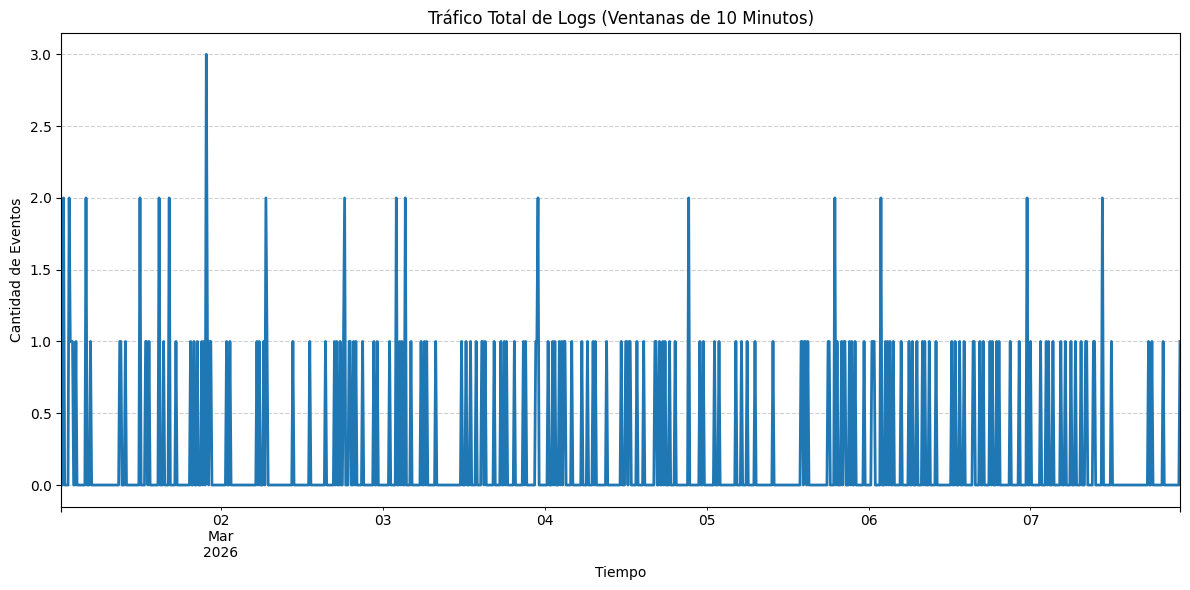

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar datos y preparar el índice de tiempo
df = pd.read_csv('logs_livecoding.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# 2. Calcular total de eventos por ventana de 10 minutos
total_eventos = df.resample('10min').size()

# 3. Calcular requests por servicio en ventanas de 10 minutos
requests_por_servicio = df.groupby([pd.Grouper(freq='10min'), 'service_name']).size().unstack(fill_value=0)

# --- RESPUESTAS A LAS PREGUNTAS ---

# Encontrar la ventana con más tráfico
ventana_pico = total_eventos.idxmax()
max_eventos = total_eventos.max()
print(f"Ventana pico: {ventana_pico} con {max_eventos} eventos.")

# Encontrar el servicio que dominó esa ventana específica
servicio_dominante = requests_por_servicio.loc[ventana_pico].idxmax()
peticiones_servicio = requests_por_servicio.loc[ventana_pico].max()
print(f"Servicio dominante: {servicio_dominante} ({peticiones_servicio} requests)")

# --- GENERAR GRÁFICO TEMPORAL ---

plt.figure(figsize=(12, 6))
total_eventos.plot(
    title='Tráfico Total de Logs (Ventanas de 10 Minutos)', 
    xlabel='Tiempo', 
    ylabel='Cantidad de Eventos', 
    color='#1f77b4',
    linewidth=2
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('grafico_trafico.png') # Guardamos el gráfico